<a href="https://colab.research.google.com/github/KweonTJ/Machine_Learning/blob/main/8_Recurrent_Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
import numpy as np

size, seq_len = 100, 3
X = np.empty(shape=(size, seq_len, 1))
Y = np.empty(shape=(size,))

for i in range(size):
  c = np.linspace(i/10., (i+seq_len-1)/10., seq_len)
  X[i] = c[:, np.newaxis]
  Y[i] = (i+seq_len-1)/10

for i in range(len(X)):
  print(X[i], Y[i])

[[0. ]
 [0.1]
 [0.2]] 0.2
[[0.1]
 [0.2]
 [0.3]] 0.3
[[0.2]
 [0.3]
 [0.4]] 0.4
[[0.3]
 [0.4]
 [0.5]] 0.5
[[0.4]
 [0.5]
 [0.6]] 0.6
[[0.5]
 [0.6]
 [0.7]] 0.7
[[0.6]
 [0.7]
 [0.8]] 0.8
[[0.7]
 [0.8]
 [0.9]] 0.9
[[0.8]
 [0.9]
 [1. ]] 1.0
[[0.9]
 [1. ]
 [1.1]] 1.1
[[1. ]
 [1.1]
 [1.2]] 1.2
[[1.1]
 [1.2]
 [1.3]] 1.3
[[1.2]
 [1.3]
 [1.4]] 1.4
[[1.3]
 [1.4]
 [1.5]] 1.5
[[1.4]
 [1.5]
 [1.6]] 1.6
[[1.5]
 [1.6]
 [1.7]] 1.7
[[1.6]
 [1.7]
 [1.8]] 1.8
[[1.7]
 [1.8]
 [1.9]] 1.9
[[1.8]
 [1.9]
 [2. ]] 2.0
[[1.9]
 [2. ]
 [2.1]] 2.1
[[2. ]
 [2.1]
 [2.2]] 2.2
[[2.1]
 [2.2]
 [2.3]] 2.3
[[2.2]
 [2.3]
 [2.4]] 2.4
[[2.3]
 [2.4]
 [2.5]] 2.5
[[2.4]
 [2.5]
 [2.6]] 2.6
[[2.5]
 [2.6]
 [2.7]] 2.7
[[2.6]
 [2.7]
 [2.8]] 2.8
[[2.7]
 [2.8]
 [2.9]] 2.9
[[2.8]
 [2.9]
 [3. ]] 3.0
[[2.9]
 [3. ]
 [3.1]] 3.1
[[3. ]
 [3.1]
 [3.2]] 3.2
[[3.1]
 [3.2]
 [3.3]] 3.3
[[3.2]
 [3.3]
 [3.4]] 3.4
[[3.3]
 [3.4]
 [3.5]] 3.5
[[3.4]
 [3.5]
 [3.6]] 3.6
[[3.5]
 [3.6]
 [3.7]] 3.7
[[3.6]
 [3.7]
 [3.8]] 3.8
[[3.7]
 [3.8]
 [3.9]] 3.9
[[3.8]
 [3.9

In [41]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(units = 20, return_sequences=False,
                              input_shape=[3,1]),
    tf.keras.layers.Dense(1)
])

model.compile(optimizer = 'adam', loss = 'mse')
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_14 (SimpleRNN)       │ (None, 20)             │           440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 461 (1.80 KB)

 Trainable params: 461 (1.80 KB)

 Non-trainable params: 0 (0.00 B)

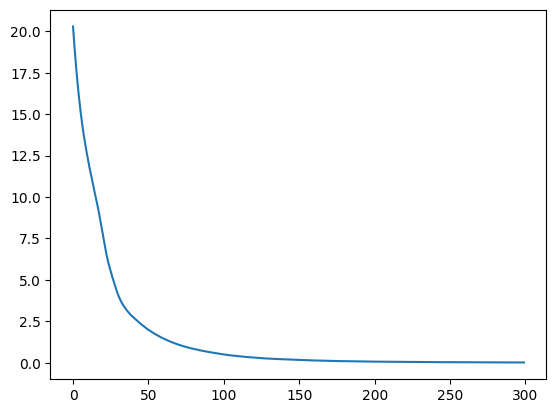

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


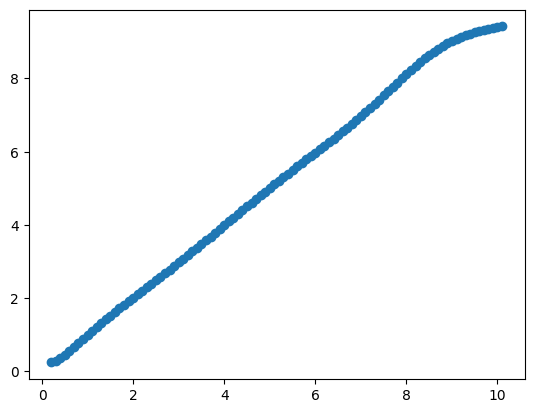

In [42]:
import matplotlib.pyplot as plt

history = model.fit(X, Y, epochs=300, verbose=0)
plt.plot(history.history['loss'])
plt.show()

y_hat = model.predict(X)
plt.scatter(Y, y_hat)
plt.show()

In [43]:
print(model.predict(np.array([[[10.2], [10.3], [10.4]]])))
print(model.predict(np.array([[[10.4], [10.5], [10.6]]])))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
[[9.462803]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
[[9.483415]]


In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

model256 = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(units = 256, return_sequences=False,
                              input_shape=[3,1]),
    tf.keras.layers.Dense(1)
])

model256.compile(optimizer = 'adam', loss = 'mse')
model256.summary()
history = model256.fit(X, Y, epochs=300, verbose=0)
plt.plot(history.history['loss'])
plt.show()

y_hat = model256.predict(X)
plt.scatter(Y, y_hat)
plt.show()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_15 (SimpleRNN)       │ (None, 256)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,305 (259.00 KB)

 Trainable params: 66,305 (259.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print(model256.predict(np.array([[[10.2], [10.3], [10.4]]])))
print(model256.predict(np.array([[[10.4], [10.5], [10.6]]])))

In [8]:
import tensorflow as tf

model_multilayer = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(units = 34, input_shape=[3,1],
                              return_sequences=True),
    tf.keras.layers.SimpleRNN(units = 34, return_sequences=True),
    tf.keras.layers.SimpleRNN(units = 34, return_sequences=True),
    tf.keras.layers.SimpleRNN(units = 34),
    tf.keras.layers.Dense(1) ])

model_multilayer.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_3 (SimpleRNN)        │ (None, 3, 34)          │         1,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_4 (SimpleRNN)        │ (None, 3, 34)          │         2,346 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_5 (SimpleRNN)        │ (None, 3, 34)          │         2,346 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_6 (SimpleRNN)        │ (None, 34)             │         2,346 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            35 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,297 (32.41 KB)

 Trainable params: 8,297 (32.41 KB)

 Non-trainable params: 0 (0.00 B)

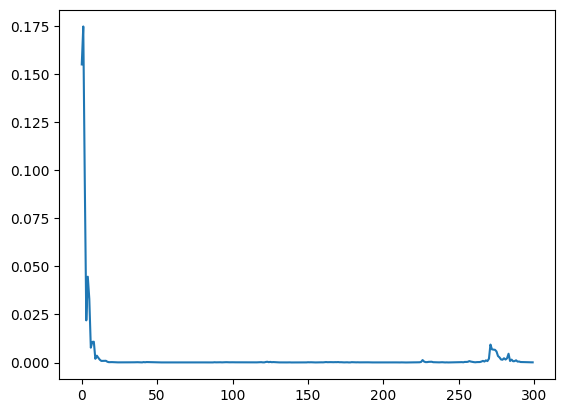

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 157ms/step


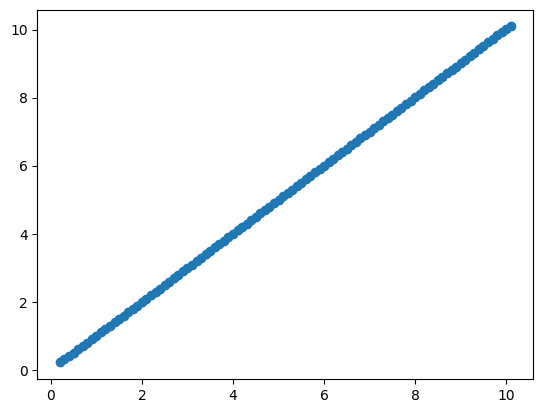

In [39]:
import matplotlib.pyplot as plt

model_multilayer.compile(optimizer = 'adam', loss = 'mse')
history = model_multilayer.fit(X, Y, epochs=300, verbose=0)
plt.plot(history.history['loss'])
plt.show()

y_hat = model_multilayer.predict(X)
plt.scatter(Y, y_hat)
plt.show()

In [34]:
print(model_multilayer.predict(np.array([[[10.2], [10.3], [10.4]]])))
print(model_multilayer.predict(np.array([[[10.4], [10.5], [10.6]]])))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
[[10.25946]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
[[10.339325]]


In [17]:
import numpy as np

def sequence_gen(size, seq_len):
  seq_X = np.empty(shape=(size, seq_len, 1))
  Y = np.empty(shape=(size,))

  for i in range(size):
    c = np.linspace(i/10, (i+seq_len-1)/10, seq_len)
    seq_X[i] = c[:, np.newaxis]
    Y[i] = (i+seq_len) / 10

  return seq_X,Y

n, seq_len = 8, 16
train_seq_X, train_y = sequence_gen(n, seq_len)

In [18]:
print('훈련용 데이터')
for i in range(n):
  print(train_seq_X[i].flatten(), train_y)

half_n, offset = int(n/2), 1.0
test_seq_X = train_seq_X[:half_n] + offset
test_Y = train_y[:half_n] + offset

print('검증용 데이터')
for i in range(half_n):
  print(test_seq_X[i].flatten(), test_Y[i])

훈련용 데이터
[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5] [1.6 1.7 1.8 1.9 2.  2.1 2.2 2.3]
[0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6] [1.6 1.7 1.8 1.9 2.  2.1 2.2 2.3]
[0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7] [1.6 1.7 1.8 1.9 2.  2.1 2.2 2.3]
[0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8] [1.6 1.7 1.8 1.9 2.  2.1 2.2 2.3]
[0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9] [1.6 1.7 1.8 1.9 2.  2.1 2.2 2.3]
[0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9 2. ] [1.6 1.7 1.8 1.9 2.  2.1 2.2 2.3]
[0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9 2.  2.1] [1.6 1.7 1.8 1.9 2.  2.1 2.2 2.3]
[0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9 2.  2.1 2.2] [1.6 1.7 1.8 1.9 2.  2.1 2.2 2.3]
검증용 데이터
[1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9 2.  2.1 2.2 2.3 2.4 2.5] 2.6
[1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9 2.  2.1 2.2 2.3 2.4 2.5 2.6] 2.7
[1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9 2.  2.1 2.2

In [31]:
import tensorflow as tf
n_units = 256
simpleRNN_model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(units = n_units, return_sequences=False,
                              input_shape=[seq_len,1]),
    tf.keras.layers.Dense(1)
])

simpleRNN_model.compile(optimizer = 'adam', loss = 'mse')
simpleRNN_model.fit(train_seq_X, train_y, epochs=100, verbose=0)

In [20]:
result = simpleRNN_model.predict(test_seq_X)
result = result.flatten()
print('예측값 :', result)
print('실제값 :', test_Y)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step
예측값 : [2.4467044 2.4963098 2.5410378 2.5813127]
실제값 : [2.6 2.7 2.8 2.9]


In [32]:
LSTM_model = tf.keras.Sequential([
    tf.keras.layers.LSTM(units = n_units, return_sequences=False,
                          input_shape=[seq_len,1]),
    tf.keras.layers.Dense(1)
])

LSTM_model.compile(optimizer='adam', loss='mse')
LSTM_model.fit(train_seq_X, train_y, epochs=100, verbose=0)

In [23]:
result = LSTM_model.predict(test_seq_X)
result = result.flatten()
print('예측값 :', result)
print('실제값 :', test_Y)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step
예측값 : [2.5680661 2.651182  2.7314954 2.809084 ]
실제값 : [2.6 2.7 2.8 2.9]


In [33]:
GRU_model = tf.keras.Sequential([
    tf.keras.layers.GRU(units = n_units, return_sequences=False,
                          input_shape=[seq_len,1]),
    tf.keras.layers.Dense(1)
])

GRU_model.compile(optimizer = 'adam', loss = 'mse')
GRU_model.fit(train_seq_X, train_y, epochs=100, verbose=0)

In [25]:
result = GRU_model.predict(test_seq_X)
result = result.flatten()
print('예측값 :', result)
print('실제값 :', test_Y)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step
예측값 : [2.580593  2.6747715 2.768311  2.8612032]
실제값 : [2.6 2.7 2.8 2.9]
